In [31]:
import os
from dotenv import load_dotenv
load_dotenv()

if os.environ['GROQ_API_KEY']:
    print("Groq API Key Set!")
else:
    raise ValueError("Groq API Key is not set!!")

Groq API Key Set!


In [32]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "openai/gpt-oss-20b")

llm.invoke("Hello!").content    

'Hello! 👋 How can I help you today?'

## **PYDANTIC LLM SCHEMA**

In [33]:
from typing import List
from pydantic import BaseModel, Field

class llm_schema(BaseModel):

    tasks : List[str] = Field(..., description="A list of tasks to be performed by the worker")
     
llm_with_schema = llm.with_structured_output(llm_schema)

## **GRAPH SCHEMA**

In [34]:
from typing import TypedDict

class graph_schema(TypedDict):

    tasks : List[str]
    query : str
    results : List[str]
    summary : str

## **ORCHESTRATOR NODE**

In [35]:
from langchain_core.prompts import ChatPromptTemplate

def orchestrator_node(state : graph_schema) -> graph_schema:

    user_query = state['query']

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are an orchestrator that breaks down a user query into tasks for the worker."),
            ("human", f"User Query: {user_query}. Please generate one prompt per task for the worker to complete.")
        ]
    )

    chain = prompt | llm_with_schema

    response = chain.invoke({"query": user_query})

    state['tasks'] = response.tasks

    return state

## **WORKER NODE**

In [44]:
def execute(query : str):

    response = llm.invoke(f"Please execute this task {query}")

    return response.content


### ThreadPoolExecutor

In [37]:
# Learn ThreadPoolExecutor & Multi Threading

from concurrent.futures import ThreadPoolExecutor

def worker_node(state : graph_schema)-> graph_schema:

    tasks = state['tasks']
    results = []

    with ThreadPoolExecutor(max_workers=len(tasks)) as executor:
        
        results_futures = executor.map(execute, tasks)
        for result in results_futures:
            results.append(result)

    state['results'] = results

    return state

## **COLLECTOR NODE**

In [47]:
def collector_node(state : graph_schema) -> graph_schema:

    results = state['results']

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a collector that summarizes the results from the worker"),
            ("user", f"Here are the results from the worker: {results}. Please summarize these results in a concise manner")
        ]
    )

    chain = prompt | llm

    summary = chain.invoke({"results" : results})

    state['summary'] = summary.content

    return state


## **STATE GRAPH**

In [39]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("orchestrator_node", orchestrator_node)
graph.add_node("worker_node", worker_node)
graph.add_node("collector_node", collector_node)

graph.add_edge(START, "orchestrator_node")
graph.add_edge("orchestrator_node", "worker_node")
graph.add_edge("worker_node", "collector_node")
graph.add_edge("collector_node", END)

orchestrator_graph = graph.compile()

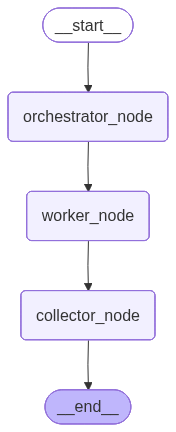

In [40]:
from IPython.display import display, Image

Image(orchestrator_graph.get_graph().draw_mermaid_png())

In [48]:
orchestrator_graph.invoke(
    {
        "query" : "What is the capital of France & What is the population of Paris? & What is the capital of Germany & what is the population of Berlin",
        "tasks" : [],
        "results" : [],
        "summary" : ""
    }
)

{'tasks': ['What is the capital of France?',
  'What is the population of Paris?',
  'What is the capital of Germany?',
  'What is the population of Berlin?'],
 'query': 'What is the capital of France & What is the population of Paris? & What is the capital of Germany & what is the population of Berlin',
 'results': ['Paris.',
  'As of the most recent estimates (2023‑2024), the population of Paris (the city proper) is about **2.1\u202fmillion people**.  \n\nIf you’re interested in the broader area, the Paris metropolitan region (Grand Paris) has a population of roughly **12\u202fmillion people**.',
  'The capital of Germany is **Berlin**.',
  'As of the most recent estimates (2024), Berlin’s population is roughly **3.7\u202fmillion people**—about 3,700,000 residents.'],
 'summary': AIMessage(content='Paris: city proper ≈\u202f2.1\u202fmillion people (2023‑24); the Greater Paris area ≈\u202f12\u202fmillion.  \nBerlin: Germany’s capital, population ≈\u202f3.7\u202fmillion (2024).', addit

In [46]:
for chunk in orchestrator_graph.stream(
   {
        "query" : "What is the capital of France & What is the population of Paris? & What is the capital of Germany & what is the population of Berlin",
        "tasks" : [],
        "results" : [],
        "summary" : ""
    },
    stream_mode="updates" 
):

    print(chunk)

{'orchestrator_node': {'tasks': ['What is the capital of France?', 'What is the population of Paris?', 'What is the capital of Germany?', 'What is the population of Berlin?'], 'query': 'What is the capital of France & What is the population of Paris? & What is the capital of Germany & what is the population of Berlin', 'results': [], 'summary': ''}}
{'worker_node': {'tasks': ['What is the capital of France?', 'What is the population of Paris?', 'What is the capital of Germany?', 'What is the population of Berlin?'], 'query': 'What is the capital of France & What is the population of Paris? & What is the capital of Germany & what is the population of Berlin', 'results': ['The capital of France is **Paris**.', '**Population of Paris (city proper)**  \n- **Estimated population (2023):** **≈\u202f2.15\u202fmillion** residents  \n  - This figure comes from the latest INSEE (French National Institute of Statistics and Economic Studies) estimates for the municipal boundaries of Paris.\n\n**Po